In [1]:
import typing as T
import pickle
import json
import os
import pathlib
import pathlib as P
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt
import math
from math import pi

In [2]:
prj_root = P.Path("__file__").absolute().parent.parent.parent
if (p := str(prj_root)) not in sys.path:
  sys.path.append(p)

In [3]:
import util.metrics as um
import sklearn.metrics as metrics

In [44]:
import numpy as np
import scipy as sci
import scipy.stats as stats
import scipy.sparse as sp
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

In [5]:
ns = ['cc', 'mf', 'bp']
ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]

In [6]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [7]:
prot_labels = []
for n in ns:
    y_label = prj_root / "data" / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [8]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)
namespace_terms = dict(zip(ontology_lst, curr_labels))

In [9]:
nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

In [10]:
ti_lst = list(nspace_ti.values())

In [11]:
# get protein name id
name_path = prj_root / "data" / "protein_name.txt"
with open(name_path, "r") as f:
    prot_lst = f.read().splitlines()# load prot names

In [12]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_lst[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }


In [13]:
ci_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(ci_path)

In [14]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)

namespace_terms = dict(zip(ontology_lst, curr_labels))

In [15]:
# load structure plddt data
plddt_path = prj_root / "data" / "protein_plddt_avgRes.csv"
plddt_df = pd.read_csv(plddt_path)

In [16]:
plddt_df = plddt_df.rename(columns={"Protein": "proteins",
                            "Avg_pLDDT": "pLDDT"})

In [17]:
plddt_df

,proteins,pLDDT
0,Q5BHH6,94.27
1,Q5BGS1,88.58
2,Q5BHC4,74.61
3,C8VRD6,83.38
4,Q5BG78,94.68
...,...,...
124068,Q96DC8,90.40
124069,Q9VAM6,91.85
124070,Q9VNF9,87.92
124071,Q9VT33,83.72


In [18]:
#%%

# load protein ic
msq_pth = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/mmseq_sim_csr.npz")
msq_mat = sp.load_npz(msq_pth)

In [19]:
# %%

# calculate the degree of each protein 
# the msq_mat is a sparse matrix where the score denote the mmseqs identity score
# when calculating the degree, all the scores are considered as 1

# copy a matrix where the scores are all 1
msq_mat_deg = msq_mat.copy()
msq_mat_deg.data = np.ones_like(msq_mat_deg.data)
# calculate the indegree of each protein
prot_deg = msq_mat_deg.sum(axis=0).A1

# create a dataframe with the protein names and their degrees
prot_deg_df = pd.DataFrame({
    "proteins": prot_lst,
    "indegree": prot_deg
}).astype({"proteins": str, "indegree": int})

In [20]:
# %%

# calculate the IC (information content) based on the degree
# first get all the number of triangular edges in the matrix
num_prots = len(prot_lst)
prot_deg_df["ic"] = np.log2(num_prots / prot_deg_df["indegree"])

In [21]:
# %%

np.quantile(prot_deg_df["ic"], np.linspace(0, 1, 20, endpoint=False))

array([4.33704172, 7.26977798, 7.56327767, 7.73100511, 7.86013374,
       7.96954496, 8.06596129, 8.14275254, 8.21347054, 8.27697348,
       8.33211504, 8.3855543 , 8.4370139 , 8.49456492, 8.55014227,
       8.61704893, 8.71625853, 8.87098112, 9.21347054, 9.93214499])

In [22]:
prot_deg_df

,proteins,indegree,ic
0,Q5BHH6,289,8.745904
1,Q5BGS1,363,8.417004
2,Q5BHC4,420,8.206584
3,C8VRD6,383,8.339629
4,Q5BG78,147,9.721157
...,...,...,...
124068,Q96DC8,305,8.668164
124069,Q9VAM6,274,8.822798
124070,Q9VNF9,392,8.306120
124071,Q9VT33,362,8.420984


In [23]:
# plddt_df = plddt_df.merge(prot_deg_df, on="proteins", how="left")

In [24]:
# load go ic
ci_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(ci_path)

In [25]:
termic_dict = dict(zip(term_count_ic["gos"], term_count_ic["ic"]))

In [26]:
# load prot labels
prot_labels = []
for n in ns:
    y_label = prj_root / "data" / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [27]:
# get protein name id
name_path = prj_root / "data" / "protein_name.txt"
with open(name_path, "r") as f:
    prot_lst = f.read().splitlines()# load prot names

In [28]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_lst[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }


In [29]:
# build a mapping from protein to its go terms
prot_labels = ft.reduce(
    opr.or_, [clt.defaultdict(list, x) for x in prot_labels]
)

In [30]:
# convert to pandas dataframe
prot_labels_df = pd.DataFrame({
    "proteins": [x for x in prot_labels.keys()],
    "go_terms": [x for x in prot_labels.values()]
})

In [31]:
prot_labels_df["ic"] = prot_labels_df["go_terms"]\
    .apply(lambda xs: np.max([t for x in xs
                               if (t := termic_dict.get(x)) is not None]))

In [32]:
prot_labels_df

,proteins,go_terms,ic
0,Q5BHH6,"[GO:0005576, GO:0110165]",3.863894
1,C8VRD6,"[GO:0005575, GO:0005622, GO:0110165]",0.361155
2,Q5BH26,"[GO:0031981, GO:0005634, GO:0140535, GO:004323...",10.018965
3,C8VUY4,"[GO:0010033, GO:0071396, GO:0070887, GO:000998...",11.021153
4,C8VUB6,"[GO:0005575, GO:0005576, GO:0110165]",3.863894
...,...,...,...
124068,Q96DC8,"[GO:0010243, GO:0070887, GO:0048584, GO:190165...",10.549848
124069,Q9VAM6,"[GO:0050801, GO:0006873, GO:0030003, GO:000998...",8.276014
124070,Q9VNF9,"[GO:1905952, GO:0051179, GO:0048518, GO:190595...",10.752665
124071,Q9VT33,"[GO:0007610, GO:0050896, GO:0042048, GO:000763...",8.996769


In [33]:
plddt_df = plddt_df.merge(prot_labels_df, on="proteins", how="left")

In [34]:
def plot_ic_by_plddt_quantiles(df):
    """
    Calculate pLDDT quantiles first, then plot violin showing IC distribution within each quantile
    """
    # Clean data
    df_clean = df.dropna(subset=['pLDDT', 'ic']).copy()
    
    # Calculate pLDDT quantiles
    n_quantiles = 20  # You can adjust this number
    df_clean['pLDDT_quantile'] = pd.qcut(df_clean['pLDDT'], 
                                        q=n_quantiles, 
                                        labels=[f'Q{i+1}' for i in range(n_quantiles)],
                                        precision=1)
    
    # Create the violin plot
    plt.figure(figsize=(12, 8))
    
    # Plot violin showing IC distribution for each pLDDT quantile
    ax = sns.violinplot(data=df_clean, x='pLDDT_quantile', y='ic', 
                       palette='viridis', inner='box', linewidth=1.5)
    
    # Customize the plot
    plt.title('IC Value Distribution Across pLDDT Quantile Groups', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('pLDDT Quantile Groups', fontsize=12)
    plt.ylabel('IC Value', fontsize=12)
    
    # Add sample sizes
    for i, quantile in enumerate(df_clean['pLDDT_quantile'].cat.categories):
        count = len(df_clean[df_clean['pLDDT_quantile'] == quantile])
        ax.text(i, ax.get_ylim()[1] * 0.98, f'n={count}', 
               ha='center', va='top', fontsize=10, fontweight='bold')
    
    # Add grid
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print pLDDT ranges for each quantile
    print("pLDDT Ranges by Quantile Group:")
    print("-" * 40)
    plddt_ranges = df_clean.groupby('pLDDT_quantile')['pLDDT'].agg(['min', 'max', 'mean']).round(2)
    print(plddt_ranges)
    
    # Print IC statistics for each quantile
    print("\nIC Statistics by pLDDT Quantile:")
    print("-" * 40)
    ic_stats = df_clean.groupby('pLDDT_quantile')['ic'].agg(['mean', 'std', 'min', 'max']).round(3)
    print(ic_stats)

In [35]:
# plot_ic_by_plddt_quantiles(plddt_df)

In [36]:
def plot_plddt_ic_violin_advanced(df):
    """
    Advanced version with multiple visualization options
    """
    # Create a copy and clean data
    df_plot = df.copy()
    df_plot = df_plot.dropna(subset=['pLDDT', 'ic'])
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('pLDDT vs IC Value Analysis', fontsize=16, fontweight='bold')
    
    # 1. Violin plot with quantile bins
    df_plot['ic_quantile'] = pd.qcut(df_plot['ic'], q=6, precision=2)
    sns.violinplot(data=df_plot, x='ic_quantile', y='pLDDT', 
                   palette='viridis', inner='quartile', ax=axes[0,0])
    axes[0,0].set_title('pLDDT Distribution by IC Quantiles')
    axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')
    axes[0,0].grid(True, alpha=0.3, axis='y')
    
    # 2. Box plot for comparison
    sns.boxplot(data=df_plot, x='ic_quantile', y='pLDDT', 
                palette='viridis', ax=axes[0,1])
    axes[0,1].set_title('pLDDT Box Plot by IC Quantiles')
    axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')
    axes[0,1].grid(True, alpha=0.3, axis='y')
    
    # 3. Scatter plot with density
    sns.scatterplot(data=df_plot, x='ic', y='pLDDT', alpha=0.6, ax=axes[1,0])
    axes[1,0].set_title('pLDDT vs IC Scatter Plot')
    axes[1,0].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_plot['ic'], df_plot['pLDDT'], 1)
    p = np.poly1d(z)
    axes[1,0].plot(df_plot['ic'], p(df_plot['ic']), "r--", alpha=0.8, linewidth=2)
    
    # Calculate correlation
    correlation = df_plot['ic'].corr(df_plot['pLDDT'])
    axes[1,0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                   transform=axes[1,0].transAxes, fontsize=12, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 4. Density plot
    sns.kdeplot(data=df_plot, x='ic', y='pLDDT', fill=True, ax=axes[1,1])
    axes[1,1].set_title('pLDDT vs IC Density Plot')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print("\nCorrelation Analysis:")
    print(f"Pearson correlation coefficient: {correlation:.4f}")
    
    from scipy.stats import spearmanr
    spearman_corr, spearman_p = spearmanr(df_plot['ic'], df_plot['pLDDT'])
    print(f"Spearman correlation coefficient: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")


In [37]:
# plot_plddt_ic_violin_advanced(plddt_df)

In [38]:
def plot_enhanced_scatter_kde(df):
    """
    Enhanced version with additional statistical information
    """
    # Create a copy and clean data
    df_plot = df.copy()
    df_plot = df_plot.dropna(subset=['pLDDT', 'ic'])
    
    # Create figure with custom layout
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 3], width_ratios=[3, 3, 1])
    
    # Main scatter plot
    ax_scatter = fig.add_subplot(gs[1, 0])
    sns.scatterplot(data=df_plot, x='ic', y='pLDDT', alpha=0.6, s=20, ax=ax_scatter)
    
    # Add trend line
    z = np.polyfit(df_plot['ic'], df_plot['pLDDT'], 1)
    p = np.poly1d(z)
    ax_scatter.plot(df_plot['ic'], p(df_plot['ic']), "r--", alpha=0.8, linewidth=2)
    ax_scatter.set_title('Scatter Plot with Trend Line', fontsize=14)
    ax_scatter.grid(True, alpha=0.3)
    
    # Main KDE plot
    ax_kde = fig.add_subplot(gs[1, 1])
    sns.kdeplot(data=df_plot, x='ic', y='pLDDT', fill=True, ax=ax_kde)
    sns.kdeplot(data=df_plot, x='ic', y='pLDDT', levels=6, colors='white', alpha=0.6, ax=ax_kde)
    ax_kde.set_title('Density Plot', fontsize=14)
    ax_kde.grid(True, alpha=0.3)
    
    # Top marginal: IC distribution
    ax_top = fig.add_subplot(gs[0, 0])
    sns.histplot(data=df_plot, x='ic', kde=True, ax=ax_top, alpha=0.7)
    ax_top.set_title('IC Distribution')
    ax_top.set_xlabel('')
    
    # Top marginal for KDE plot
    ax_top2 = fig.add_subplot(gs[0, 1])
    sns.histplot(data=df_plot, x='ic', kde=True, ax=ax_top2, alpha=0.7)
    ax_top2.set_title('IC Distribution')
    ax_top2.set_xlabel('')
    
    # Right marginal: pLDDT distribution
    ax_right = fig.add_subplot(gs[1, 2])
    sns.histplot(data=df_plot, y='pLDDT', kde=True, ax=ax_right, alpha=0.7)
    ax_right.set_title('pLDDT Distribution', rotation=90, x=1.1, y=0.5)
    ax_right.set_ylabel('')
    
    # Calculate correlations
    pearson_corr = df_plot['ic'].corr(df_plot['pLDDT'])
    spearman_corr, spearman_p = stats.spearmanr(df_plot['ic'], df_plot['pLDDT'])
    
    # Add correlation info to scatter plot
    ax_scatter.text(0.05, 0.95, f'Pearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}', 
                   transform=ax_scatter.transAxes, fontsize=12, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                   verticalalignment='top')
    
    plt.suptitle('Enhanced pLDDT vs IC Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Statistical Analysis:")
    print("=" * 40)
    print(f"Sample size: {len(df_plot):,}")
    print(f"Pearson correlation: {pearson_corr:.4f}")
    print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
    print(f"\nIC Statistics:")
    print(f"  Mean: {df_plot['ic'].mean():.3f}")
    print(f"  Std:  {df_plot['ic'].std():.3f}")
    print(f"  Range: {df_plot['ic'].min():.3f} - {df_plot['ic'].max():.3f}")
    print(f"\npLDDT Statistics:")
    print(f"  Mean: {df_plot['pLDDT'].mean():.3f}")
    print(f"  Std:  {df_plot['pLDDT'].std():.3f}")
    print(f"  Range: {df_plot['pLDDT'].min():.3f} - {df_plot['pLDDT'].max():.3f}")

In [39]:
# plot_enhanced_scatter_kde(plddt_df)

In [40]:
# def plot_joint_distribution(df):
#     """
#     Create a joint plot combining scatter, KDE, and marginal distributions
#     """
#     # Create a copy and clean data
#     df_plot = df.copy()
#     df_plot = df_plot.dropna(subset=['pLDDT', 'ic'])
    
#     # Create joint plot
#     g = sns.JointGrid(data=df_plot, x='ic', y='pLDDT', height=10)
    
#     # Main plot: scatter + KDE contours
#     g.plot_joint(sns.scatterplot, alpha=0.5, s=15)
#     g.plot_joint(sns.kdeplot, levels=6, colors='red', alpha=0.7)
    
#     # Marginal plots: histograms with KDE
#     g.plot_marginals(sns.histplot, kde=True, alpha=0.7)
    
#     # Add trend line to main plot
#     z = np.polyfit(df_plot['ic'], df_plot['pLDDT'], 1)
#     p = np.poly1d(z)
#     g.ax_joint.plot(df_plot['ic'], p(df_plot['ic']), "orange", linewidth=3, alpha=0.8)
    
#     # Calculate correlations
#     pearson_corr = df_plot['ic'].corr(df_plot['pLDDT'])
#     spearman_corr, spearman_p = stats.spearmanr(df_plot['ic'], df_plot['pLDDT'])
    
#     # Add correlation info
#     g.ax_joint.text(0.05, 0.95, f'Pearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}', 
#                    transform=g.ax_joint.transAxes, fontsize=12, 
#                    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9),
#                    verticalalignment='top')
    
#     # # Set title
#     # g.figure.suptitle('Joint Distribution: pLDDT vs IC Value', fontsize=16, fontweight='bold', y=0.98)
    
#     plt.show()
    
#     return g

In [59]:
def plot_joint_distribution_enhanced(df):
    """
    Enhanced version with better magma colormap integration
    """
    # Create a copy and clean data
    df_plot = df.copy()
    df_plot = df_plot.dropna(subset=['pLDDT', 'ic'])
    
    # Create joint plot
    g = sns.JointGrid(data=df_plot, x='ic', y='pLDDT', height=10)

    # Create custom colormap normalization for better contrast
    ic_min, ic_max = df_plot['ic'].min(), df_plot['ic'].max()
    norm = colors.Normalize(vmin=ic_min, vmax=ic_max)
    
    # Main plot: scatter with magma colormap
    scatter = g.ax_joint.scatter(df_plot['ic'], df_plot['pLDDT'], 
                                c=df_plot['ic'], cmap='magma', norm=norm,
                                alpha=0.7, s=20, edgecolors='none')
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=g.ax_joint, 
                        # shrink=0.8
                        )
    cbar.set_label('Max IC Value', rotation=270, labelpad=20, fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    # Add KDE contours with white color for contrast
    g.plot_joint(sns.kdeplot, levels=8, colors='white', alpha=0.9, linewidths=2)
    
    # Marginal plots with magma-inspired colors
    g.plot_marginals(sns.histplot, kde=True, alpha=0.6, 
                    color='#440154', edgecolor='white', linewidth=0.5)
    
    # Add trend line - use cyan for good contrast with magma
    z = np.polyfit(df_plot['ic'], df_plot['pLDDT'], 1)
    p = np.poly1d(z)
    g.ax_joint.plot(df_plot['ic'], p(df_plot['ic']), 
                   color='cyan', linewidth=4, alpha=0.9, 
                   linestyle='--', label='Trend Line')
    
    # Calculate correlations
    pearson_corr = df_plot['ic'].corr(df_plot['pLDDT'])
    spearman_corr, spearman_p = stats.spearmanr(df_plot['ic'], df_plot['pLDDT'])
    
    # Add correlation info with better styling
    info_text = f'Pearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}\nn = {len(df_plot):,}'
    g.ax_joint.text(0.05, 0.95, info_text,
                   transform=g.ax_joint.transAxes, fontsize=12, 
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="white", 
                           alpha=0.95, edgecolor='gray'),
                   verticalalignment='top')
    
    # Customize axis labels and title
    g.ax_joint.set_xlabel('GO IC', fontsize=36)
    g.ax_joint.set_ylabel('pLDDT', fontsize=36)
    g.ax_joint.grid(True, alpha=0.3)

    g.ax_joint.set_facecolor('#F2F2F2')
    
#     # Add title
#     g.figure.suptitle('Joint Distribution: pLDDT vs IC Value (Magma Colormap)', 
#                    fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    return g


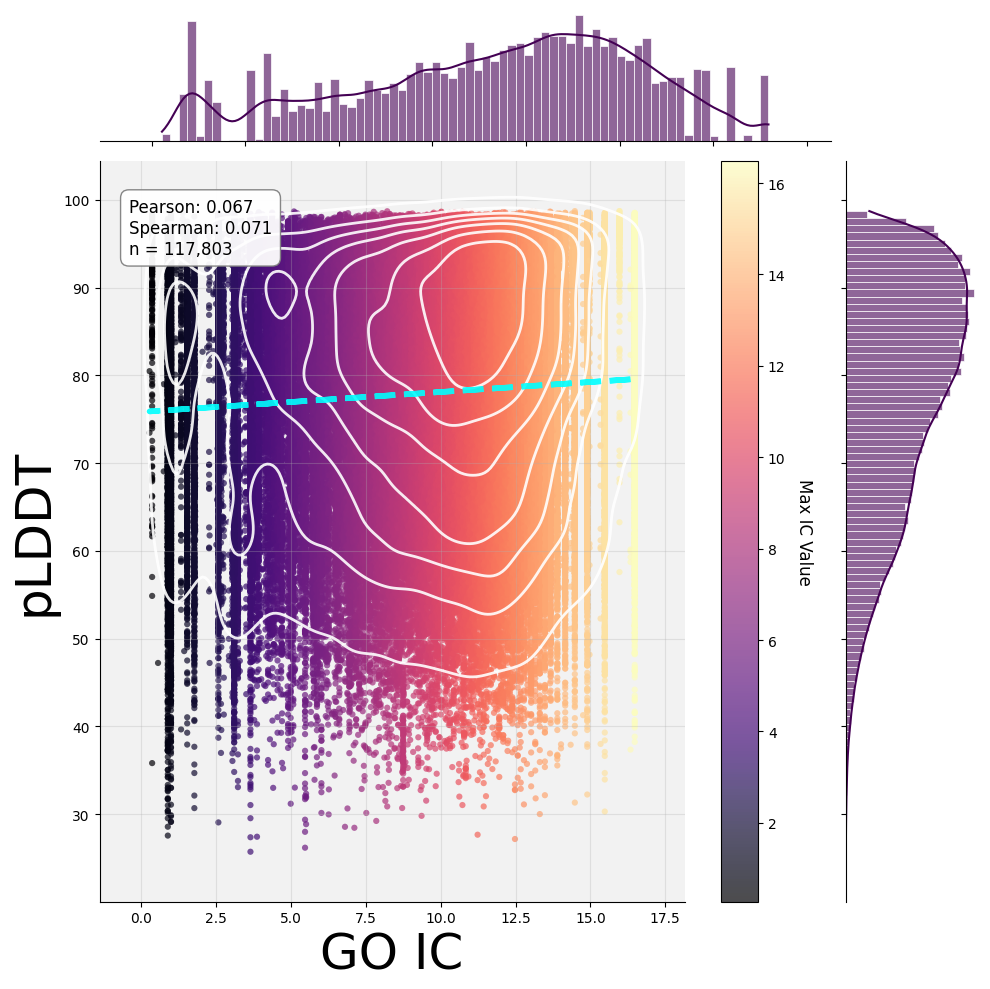

In [60]:
fig = plot_joint_distribution_enhanced(plddt_df)

In [61]:
save_dir = prj_root / "notebooks" / "inductive_learning" / "figures"
save_path = save_dir / "plddt_ic_distribution_1.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
save_path = save_dir / "plddt_ic_distribution_1.svg"
fig.savefig(save_path, bbox_inches="tight")